In [13]:
# 1.Import Necessary Libraries

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression

In [15]:
# 2.Data Collection

In [4]:
cars_df = pd.read_csv("Cars.csv")

In [5]:
cars_df.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [16]:
# 3.Data Understanding

In [7]:
# 3.1 Perform Initial Investigation on the data

In [8]:
cars_df.shape

(81, 5)

In [11]:
cars_df.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [12]:
cars_df.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [17]:
cars_df.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [18]:
# Now Let check for the assumptions

In [19]:
# Test 1. Linearity Test

In [21]:
cars_df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


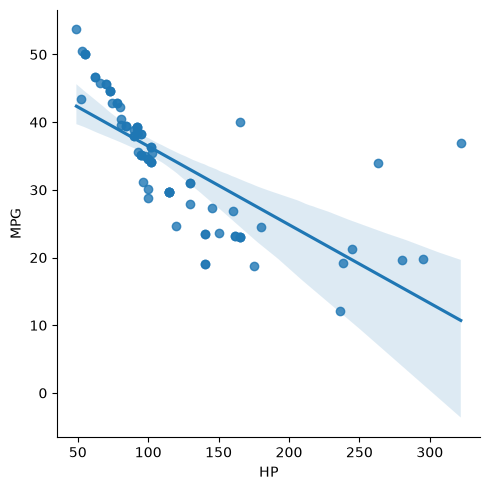

In [22]:
sns.lmplot(data=cars_df,x="HP",y="MPG")

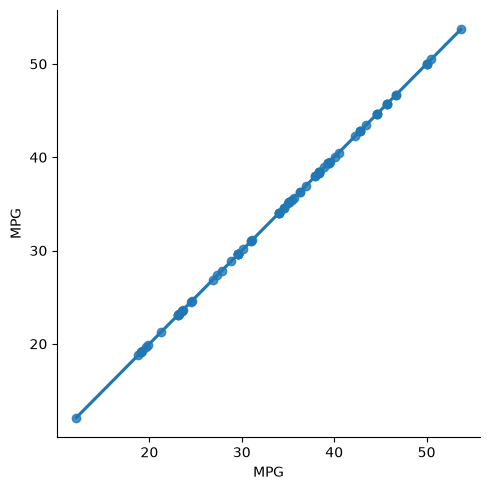

In [23]:
sns.lmplot(data=cars_df,x="MPG",y="MPG")

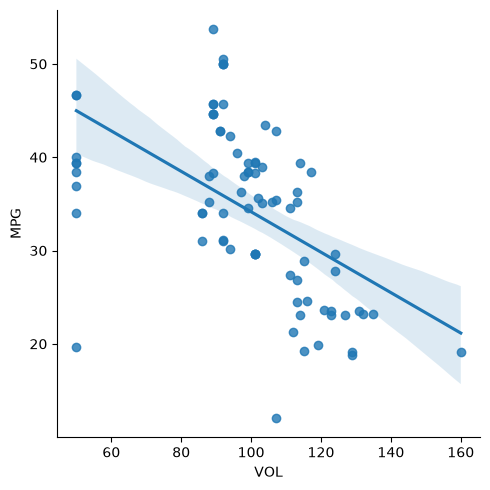

In [24]:
sns.lmplot(data=cars_df,x="VOL",y="MPG")

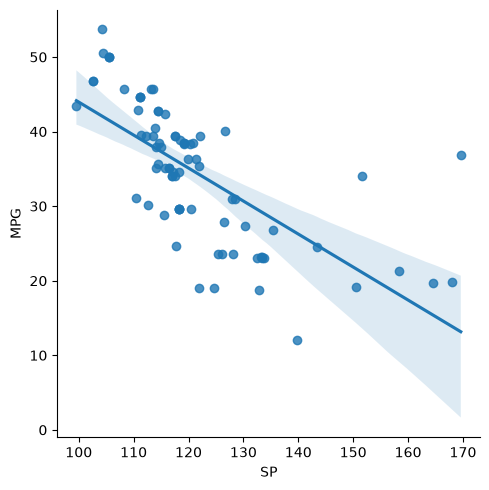

In [25]:
sns.lmplot(data=cars_df,x="SP",y="MPG")

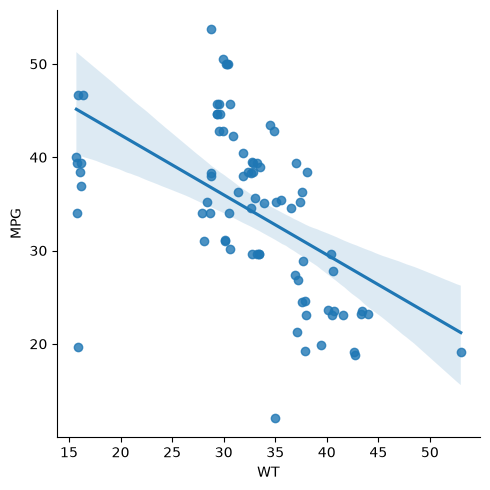

In [26]:
sns.lmplot(data=cars_df,x="WT",y="MPG")

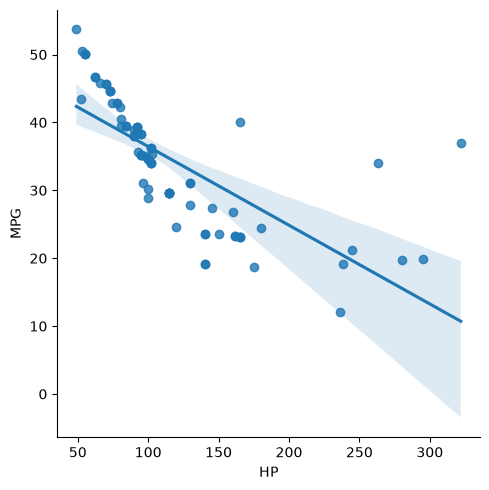

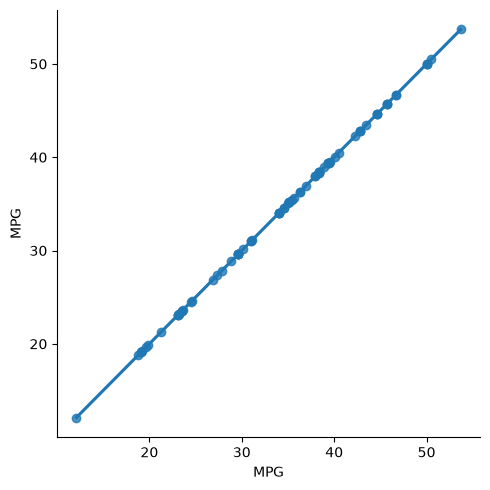

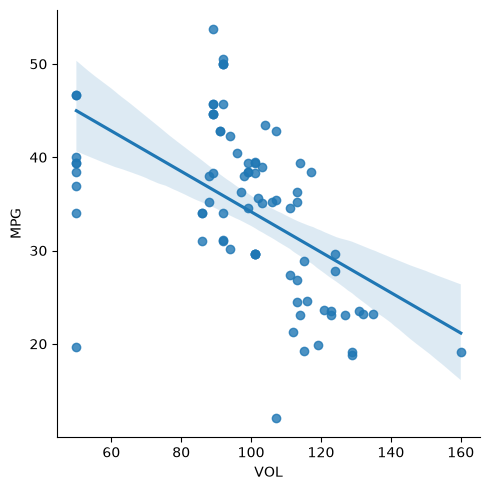

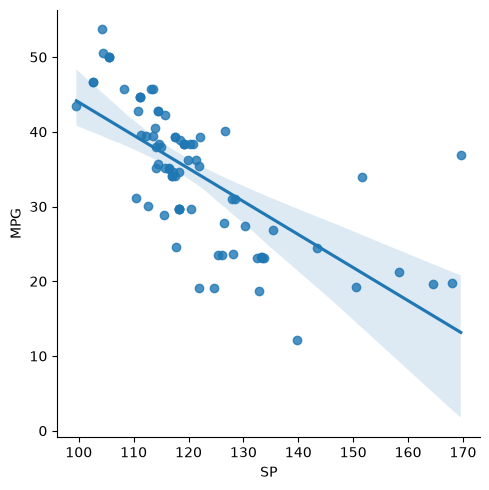

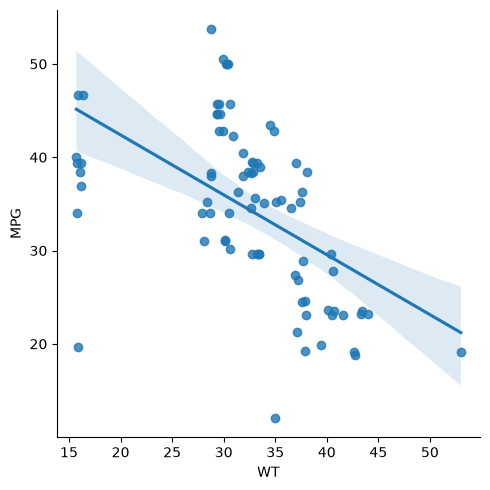

In [27]:
for i in cars_df:
    sns.lmplot(data=cars_df,x=i,y="MPG")

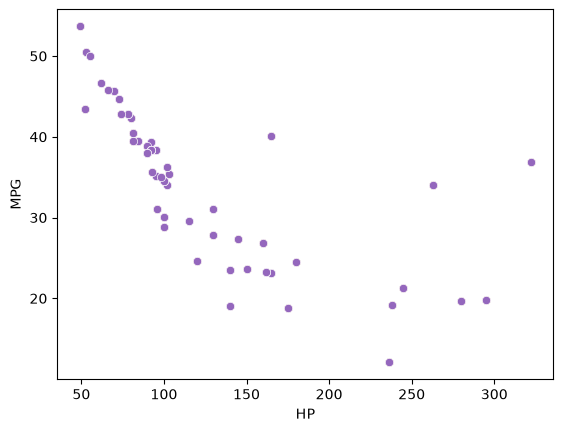

In [31]:
for i in cars_df:
    sns.scatterplot(data=cars_df,x="HP",y="MPG")

In [28]:
# Test - 1 Linearity Test Failed.

In [29]:
# Test 2 Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

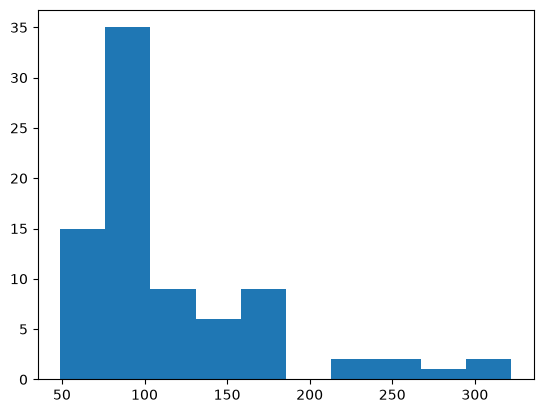

In [32]:
plt.hist(cars_df["HP"])

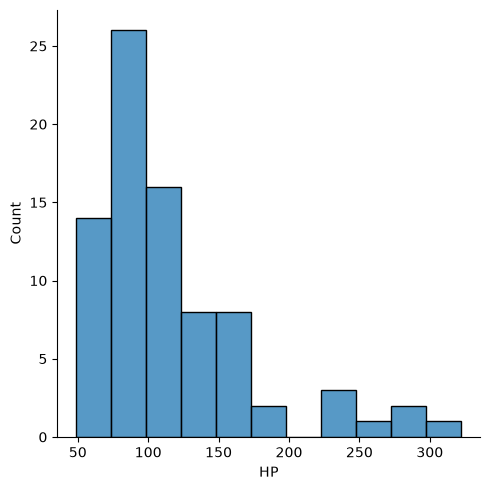

In [35]:
sns.displot(x=cars_df["HP"])

<Axes: ylabel='Density'>

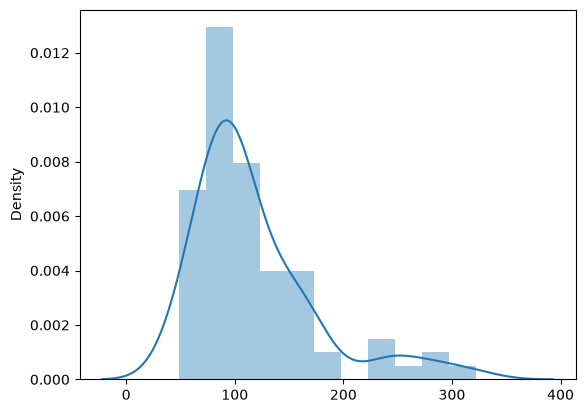

In [36]:
sns.distplot(x=cars_df["HP"])

In [37]:
# Test - 2 Normality test failed

In [42]:
# Test 3 Multi-colinearity test

In [40]:
cars_df.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


In [43]:
corr_matrix = cars_df.corr()

In [44]:
"""
weak correlation = 0 to 0.20
less correlation = 0.21 to 0.40
moderate correlation = 0.41 to 0.60
high correlation = 0.61 to 0.80
very high correlation = 0.81 to 0.1
"""

'\nweak correlation = 0 to 0.20\nless correlation = 0.21 to 0.40\nmoderate correlation = 0.41 to 0.60\nhigh correlation = 0.61 to 0.80\nvery high correlation = 0.81 to 0.1\n'

<Axes: >

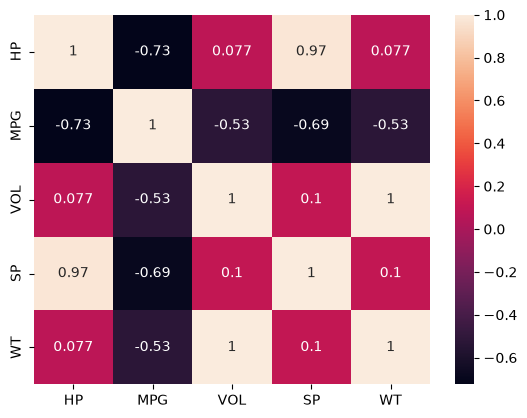

In [46]:
sns.heatmap(data=corr_matrix,annot=True)

In [47]:
# Test -3 there is multicolinearity in this data

In [48]:
# Test 4 No auto regression

In [49]:
# NO Time dependent data

In [50]:
# Test 4 Auto Regression Passed.

In [51]:
# Homoscadasticity test

In [53]:
# Zero Residual Mean Test

In [54]:
# 4. Data Preparation

In [60]:
cars_df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [61]:
X = cars_df.drop(labels=["MPG"],axis=1)

In [62]:
y = cars_df["MPG"]

In [55]:
# There is nothing to prepare because all features are numeric

In [56]:
# 5. Model Building

In [58]:
linear_model = LinearRegression()

In [59]:
# 6. Model Training

In [63]:
linear_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.21,-0.34, 0.4 , 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [69]:
linear_model.intercept_

np.float64(30.67733585215165)

In [68]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

In [64]:
# 7. Model Testing

In [65]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [66]:
y_pred = linear_model.predict(X)

In [71]:
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

In [72]:
# 8.Model Evaluation

In [73]:
y-y_pred

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [75]:
error = y-y_pred

In [76]:
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [77]:
## Let's now perform homoscadasticity test

In [78]:
# Error should be similar.

In [82]:
cars_df["error"]=error
cars_df.head()

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584


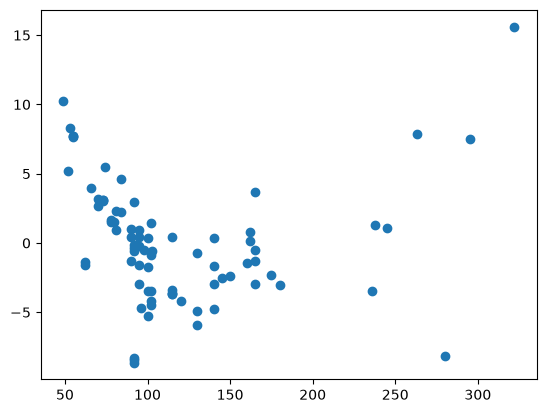

In [86]:
plt.scatter(data=cars_df,x="HP",y="error")

In [87]:
del cars_df["error"]

<Axes: xlabel='HP', ylabel='MPG'>

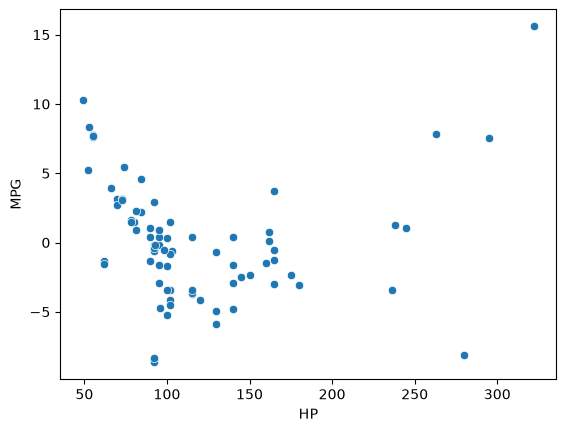

In [88]:
sns.scatterplot(data=cars_df,x="HP",y=error)

In [89]:
# Homoscadasticity test failed.

In [90]:
# test 6. Zero residual mean test

<Axes: xlabel='MPG'>

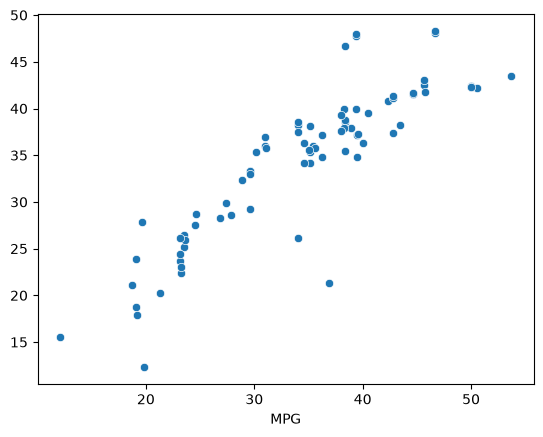

In [91]:
sns.scatterplot(x=y,y=y_pred)

In [92]:
# Test 6 zero residual mean failed.

In [93]:
# 9. Model deployment

In [94]:
from pickle import dump

In [95]:
dump(obj=linear_model,file=open(file='linear_intelligence_file.pkl',mode='wb'))